## Synthetic Image generation

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from glob import glob

# Parameters
input_folder = '/content/drive/MyDrive/test/low'  # Path to the LOW class image folder
output_folder = '/content/drive/MyDrive/Aug_Low'  # Path to save synthetic images
target_count = 250  # Target number of images in the LOW class

# Create output directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Get all images in the LOW class folder
image_paths = glob(os.path.join(input_folder, '*.jpg'))  # Adjust extension if needed

# Number of current images
current_count = len(image_paths)

# Check if augmentation is needed
if current_count >= target_count:
    print("The LOW class already has enough images.")
else:
    # Calculate how many synthetic images are needed
    needed_images = target_count - current_count

    # Augmentation parameters
    augmentations = [
        lambda img: cv2.flip(img, 1),  # Horizontal flip
        lambda img: cv2.GaussianBlur(img, (5, 5), 0),  # Gaussian blur
        #lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),  # Grayscale conversion
        lambda img: cv2.addWeighted(img, 1.5, np.zeros(img.shape, img.dtype), 0, -100),  # Brightness adjustment
        lambda img: cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 15, 1.0), (img.shape[1], img.shape[0])),  # Rotation
        lambda img: cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), -15, 1.0), (img.shape[1], img.shape[0])),  # Rotation (negative)
    ]

    # Generate synthetic images until we reach the desired count
    generated_count = 0

    while generated_count < needed_images:
        for image_path in image_paths:
            if generated_count >= needed_images:
                break

            # Load image
            img = cv2.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

            # Apply augmentations and save new images
            for augment in augmentations:
                augmented_img = augment(img)
                new_image_name = f'synthetic_{generated_count + current_count}.jpg'
                new_image_path = os.path.join(output_folder, new_image_name)

                # Save augmented image
                Image.fromarray(augmented_img).save(new_image_path)
                generated_count += 1

                if generated_count >= needed_images:
                    break

print(f"Synthetic data generation complete. {generated_count} new images created.")

## Downsampling of data

In [ ]:
import os
import random
import shutil

# Paths
input_folder = '/content/drive/MyDrive/test/high'  # Path to the HIGH class folder
output_folder = '/content/drive/MyDrive/aug_high'  # Path to save the balanced HIGH class
os.makedirs(output_folder, exist_ok=True)

# Get list of images in the HIGH class folder
image_files = [f for f in os.listdir(input_folder) if f.endswith(('jpg', 'jpeg', 'png'))]

# Check if downsampling is needed
if len(image_files) > 250:
    # Randomly select 250 images from the HIGH class
    selected_images = random.sample(image_files, 250)

    # Copy selected images to the output folder
    for image in selected_images:
        src_path = os.path.join(input_folder, image)
        dst_path = os.path.join(output_folder, image)
        shutil.copy(src_path, dst_path)

    print(f"Balanced HIGH class: Selected 250 images from {len(image_files)} original images.")
else:
    print(f"No downsampling needed. The HIGH class already has {len(image_files)} images or fewer.")


In [ ]:
from inference_sdk import InferenceHTTPClient

# create an inference client
CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="rpQR9FjjXOAiCgDzewps"
)

# run inference on a local image
print(CLIENT.infer(
    "/content/test_image2.jpeg",
    model_id="fire-domain/1"
))

{'inference_id': 'a1d0ec8a-e4a0-4318-bfdb-3095d4742552', 'time': 0.27674589100024605, 'image': {'width': 305, 'height': 165}, 'predictions': [{'class': 'HIGH', 'class_id': 1, 'confidence': 0.8574}, {'class': 'MEDIUM', 'class_id': 2, 'confidence': 0.0749}, {'class': 'NO', 'class_id': 0, 'confidence': 0.0366}, {'class': 'LOW', 'class_id': 3, 'confidence': 0.0311}], 'top': 'HIGH', 'confidence': 0.8574}


In [ ]:
!pip install inference_sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.0.0
    Uninstalling pillow-11.0.0:
      Successfully uninstalled pillow-11.0.0
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.11.10
    Uninstalling aiohttp-3.11.10:
      Successfully uninstalled aiohttp-3.11.10


In [ ]:
import os
from sklearn.metrics import classification_report
from inference_sdk import InferenceHTTPClient

# Create an inference client
CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="rpQR9FjjXOAiCgDzewps"
)

# Folder containing subfolders of images for each class
base_folder = "/content/drive/MyDrive/test"  # Path to the test folder

# Initialize lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate over each subfolder (class) in the test folder
for class_folder in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_folder)

    # Skip if not a directory (e.g., hidden files or other non-class folders)
    if not os.path.isdir(class_path):
        continue

    # Iterate over all image files in the current class folder
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        # Check if it's an image file (e.g., jpg, png, etc.)
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            # True label is the folder name (class name)
            true_labels.append(class_folder)

            # Run inference on the image
            result = CLIENT.infer(image_path, model_id="fire-domain/1")

            # Extract the predicted label (assuming 'class' field exists in the result)
            predicted_label = result.get('predictions', [])[0].get('class', '')
            predicted_labels.append(predicted_label)

# Print the classification report
print(classification_report(true_labels, predicted_labels))



              precision    recall  f1-score   support

        HIGH       0.52      0.86      0.65        14
         LOW       0.85      0.85      0.85        27
      MEDIUM       0.76      0.46      0.58        28
          NO       0.94      1.00      0.97        30

    accuracy                           0.79        99
   macro avg       0.77      0.79      0.76        99
weighted avg       0.81      0.79      0.78        99



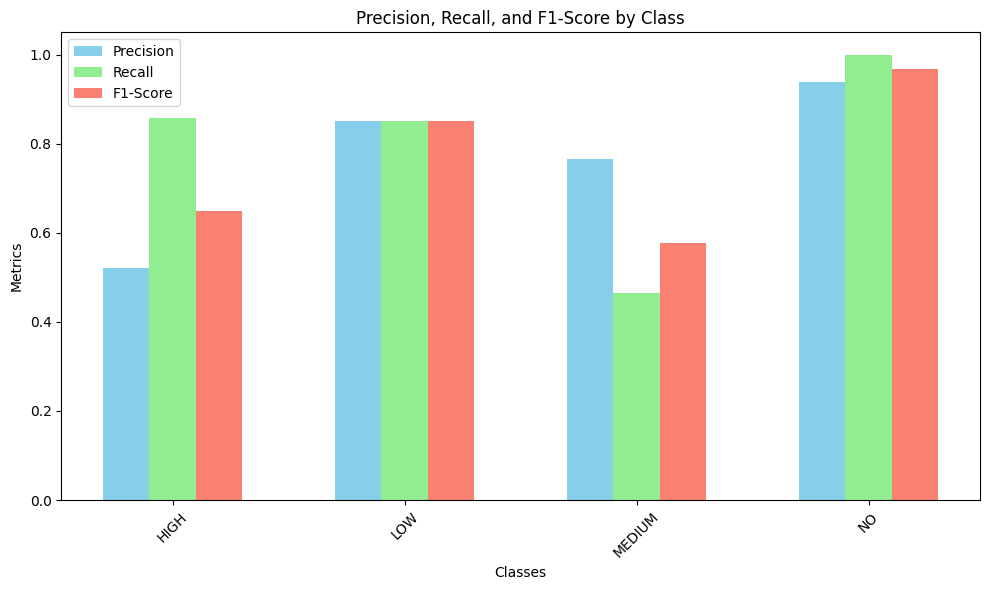

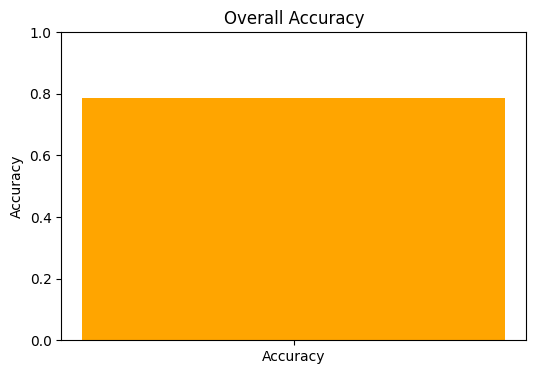

In [ ]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
import numpy as np

# Encode labels numerically for evaluation
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)
predicted_labels_encoded = label_encoder.transform(predicted_labels)

# Calculate metrics
precision, recall, f1_score, _ = precision_recall_fscore_support(true_labels_encoded, predicted_labels_encoded, average=None)
accuracy = accuracy_score(true_labels_encoded, predicted_labels_encoded)
classes = label_encoder.classes_

# Plot Precision, Recall, and F1-Score
x = np.arange(len(classes))  # the label locations
width = 0.2  # width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-Score', color='salmon')

plt.xlabel('Classes')
plt.ylabel('Metrics')
plt.title('Precision, Recall, and F1-Score by Class')
plt.xticks(x, classes, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Accuracy
plt.figure(figsize=(6, 4))
plt.bar(['Accuracy'], [accuracy], color='orange')
plt.ylabel('Accuracy')
plt.title('Overall Accuracy')
plt.ylim(0, 1)
plt.show()

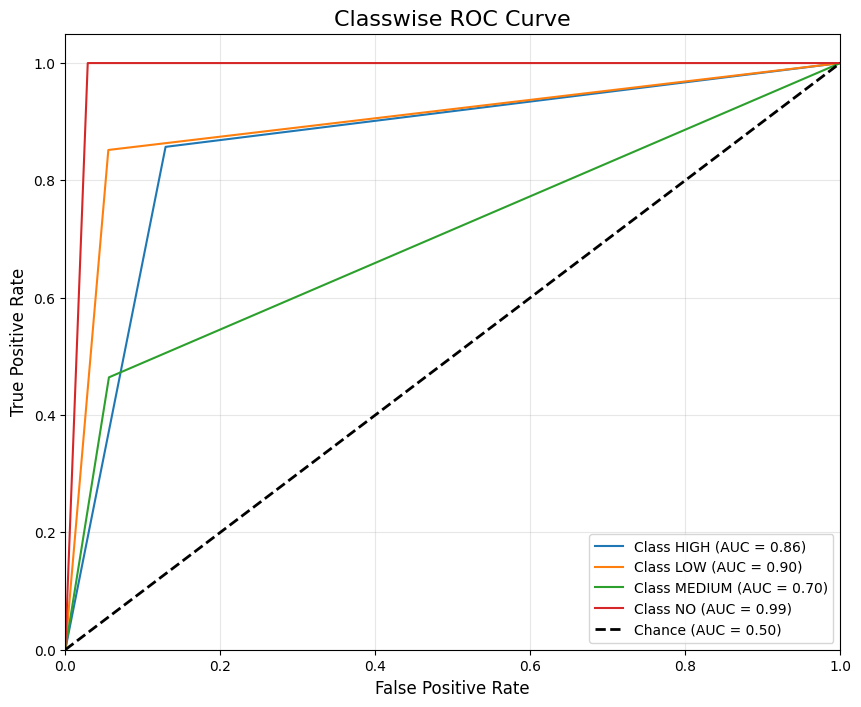

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Assuming 'true_labels' and 'predicted_labels' are already defined
# Encode the true and predicted labels into numerical format
label_encoder = LabelBinarizer()
true_labels_binarized = label_encoder.fit_transform(true_labels)
predicted_probs = []  # Placeholder for predicted probabilities

# If your inference API doesn't provide class probabilities, create mock probabilities
# In practice, replace this with your model's probability outputs.
num_classes = len(label_encoder.classes_)
for pred_label in predicted_labels:
    prob = [0] * num_classes
    if pred_label in label_encoder.classes_:
        prob[label_encoder.classes_.tolist().index(pred_label)] = 1
    predicted_probs.append(prob)

predicted_probs = np.array(predicted_probs)

# Plotting classwise ROC curves
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Classwise ROC Curve', fontsize=16)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CNN Model

## importing libraries


In [ ]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive
from sklearn.metrics import classification_report

## Data Set

In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

# Define paths
dataset_path = "/content/drive/MyDrive/Fire detect (1)"
output_path = "/content/split_dataset11"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define splits
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create output directories
for split in ['train1', 'val1', 'test1']:
    for class_name in ['HIGH (1)', 'MEDIUM (1)', 'LOW (1)', 'Fake']:
        os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# Split data
def split_data():
    for class_name in ['HIGH (1)', 'MEDIUM (1)', 'LOW (1)', 'Fake']:
        source_folder = os.path.join(dataset_path, class_name)
        images = os.listdir(source_folder)
        np.random.shuffle(images)

        train_split = int(len(images) * train_ratio)
        val_split = int(len(images) * (train_ratio + val_ratio))

        for i, image in enumerate(images):
            if i < train_split:
                dest_folder = os.path.join(output_path, 'train1', class_name)
            elif i < val_split:
                dest_folder = os.path.join(output_path, 'val1', class_name)
            else:
                dest_folder = os.path.join(output_path, 'test1', class_name)
            shutil.copy(os.path.join(source_folder, image), os.path.join(dest_folder, image))

split_data()


In [ ]:
# Define data generators
datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = datagen.flow_from_directory(
    os.path.join(output_path, 'train1'),
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)
val_gen = datagen.flow_from_directory(
    os.path.join(output_path, 'val1'),
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)
test_gen = datagen.flow_from_directory(
    os.path.join(output_path, 'test1'),
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 693 images belonging to 4 classes.
Found 148 images belonging to 4 classes.
Found 150 images belonging to 4 classes.


In [ ]:
# Define a custom CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

# Evaluate the model
eval_results = model.evaluate(test_gen)
print(f"Test Accuracy: {eval_results[1] * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.3563 - loss: 1.4732 - val_accuracy: 0.5473 - val_loss: 1.0318
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4908 - loss: 1.1003 - val_accuracy: 0.5338 - val_loss: 0.9595
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.5419 - loss: 1.0096 - val_accuracy: 0.6081 - val_loss: 0.9481
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.5678 - loss: 0.9588 - val_accuracy: 0.5676 - val_loss: 0.9703
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.5603 - loss: 1.0253 - val_accuracy: 0.6689 - val_loss: 0.8309
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.6482 - loss: 0.7947 - val_accuracy: 0.6959 - val_loss: 0.8287
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.7118 - loss: 0.6600 - val_accuracy: 0.6757 - val_loss: 0.8234
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.7629 - loss: 0.6072 - val_accuracy: 0.6

In [ ]:
# Save the model
model.save('/content/drive/My Drive/custom_cnn_model.h5')



In [ ]:
# Load and test the model with a single image
def predict_image(image_path):
    model = load_model('/content/drive/My Drive/custom_cnn_model.h5')
    image = load_img(image_path, target_size=(128, 128))
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    predictions = model.predict(image_array)
    class_indices = {v: k for k, v in train_gen.class_indices.items()}
    predicted_class = class_indices[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    print(f"Predicted Class: {predicted_class}, Confidence: {confidence:.2f}%")

In [ ]:
predict_image("/content/images.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
Predicted Class: HIGH (1), Confidence: 53.25%


# Resnet50


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pretrained ResNet50 model without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze base model layers
base_model.trainable = False

# Add custom layers for classification
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# Evaluate the model
eval_results = model.evaluate(test_gen)
print(f"Test Accuracy: {eval_results[1] * 100:.2f}%")


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 639ms/step - accuracy: 0.2268 - loss: 1.5627 - val_accuracy: 0.2500 - val_loss: 1.3820
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.2572 - loss: 1.4116 - val_accuracy: 0.2635 - val_loss: 1.3784
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.2839 - loss: 1.3833 - val_accuracy: 0.3108 - val_loss: 1.3701
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.2931 - loss: 1.3868 - val_accuracy: 0.3108 - val_loss: 1.3674
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.3436 - loss: 1.3695 - val_accuracy: 0.2635 - val_loss: 1.3653
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.2654 - loss: 1.3749 - val_accuracy: 0.3784 - val_loss: 1.3613
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.3039 - loss: 1.3697 - val_accuracy: 0.2432 - val_loss: 1.3579
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.3322 - loss: 1.3605 - val_accuracy: 0

## Mobilenet

In [ ]:
from tensorflow.keras.applications import MobileNet

# Load MobileNet model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze the base model

# Add custom layers
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# Evaluate the model
eval_results = model.evaluate(test_gen)
print(f"Test Accuracy: {eval_results[1] * 100:.2f}%")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 470ms/step - accuracy: 0.3839 - loss: 1.6414 - val_accuracy: 0.5811 - val_loss: 0.9209
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5720 - loss: 0.9168 - val_accuracy: 0.6149 - val_loss: 0.8391
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6573 - loss: 0.7582 - val_accuracy: 0.6824 - val_loss: 0.7483
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7318 - loss: 0.6512 - val_accuracy: 0.6892 - val_loss: 0.7130
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7991 - loss: 0.4909 - val_accuracy: 0.7162 - val_loss: 0.6691
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.8070 - loss: 0.5059 - val_accuracy: 0.7230 - val_loss: 0.6813
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8633 - loss: 0.3630 - val_accuracy: 0.7365 - val_loss: 0.6512
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accu

In [ ]:
# Save the model
model.save('/content/drive/My Drive/MobileNet_model.h5')

In [ ]:
import tensorflow as tf
import json
import os

# Load your existing H5 model
model = tf.keras.models.load_model("/MobileNet_model (1).h5")

# Create directory for Hugging Face if it doesn't exist
os.makedirs("mobilenet_fire_repo", exist_ok=True)

# Save the model in the SavedModel format
model.export("/content/drive/My Drive/MobileNet_Savedmodel")

# Save the model weights separately
#model.save_weights("mobilenet_fire_repo/model.weights.h5")

# For the config, we'll create a simple metadata file
'''model_metadata = {
    "input_shape": [128, 128, 3],
    "num_classes": 4,
    "model_type": "MobileNet",
    "base_trainable": False
}

with open("mobilenet_fire_repo/metadata.json", "w") as f:
    json.dump(model_metadata, f)
'''
print("Files prepared for Hugging Face repo:")
print("- mobilenet_fire_repo/saved_model/")
print("- mobilenet_fire_repo/mobilenet_fire_weights.h5")
print("- mobilenet_fire_repo/metadata.json")
print("- mobilenet_fire_repo/config.json")

Saved artifact at '/content/drive/My Drive/MobileNet_Savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_15')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132884086608080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086608656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086610384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086610000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086608848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086610576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086609040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086610960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086609232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132884086609808: TensorSpec(shape=(), dtype=tf.resourc

In [ ]:
!pip install tf2onnx==1.14.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.2.10
    Uninstalling flatbuffers-25.2.10:
      Successfully uninstalled flatbuffers-25.2.10
  Attempting uninstall: tf2onnx
    Found existing installation: tf2onnx 1.16.1
    Uninstalling tf2onnx-1.16.1:
      Successfully uninstalled tf2onnx-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires flatbuffers>=24.3.25, but you have flatbuffers 2.0.7 which is incompatible.


In [ ]:
import tensorflow as tf
import onnx
import tf2onnx

model = tf.keras.models.load_model('/content/drive/MyDrive/MobileNet_Savedmodel')
input_signature = [tf.TensorSpec(model.input_shape, tf.float32)]
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature)
tf2onnx.save_model(onnx_model, 'mobilenet_model.onnx')

ValueError: File format not supported: filepath=/content/drive/MyDrive/MobileNet_Savedmodel. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/content/drive/MyDrive/MobileNet_Savedmodel, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [ ]:
print(tf2onnx.__version__)

1.14.0


In [ ]:
import tf2onnx
import tensorflow as tf
model_path= "/MobileNet_model.keras"
model = tf.keras.models.load_model(model_path)

# Convert from SavedModel
onnx_model, _ = tf2onnx.convert.from_keras(model, opset=13)

# Save the ONNX model
with open("model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX model converted from SavedModel successfully!")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


AttributeError: 'Sequential' object has no attribute 'output_names'

In [ ]:
!pip install --upgrade tensorflow keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 833.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.0 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 2.0.7
    Uninstalling flatbuffers-2.0.7:
      Successfully uninstalled flatbuffers-2.0.7
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tens

In [ ]:
import tensorflow as tf
import tf2onnx
import os

def convert_pb_to_onnx(model_path, output_path='model.onnx'):
    try:
        # Load the saved model
        model = tf.saved_model.load(model_path)

        # If it's a concrete function, get the function
        if hasattr(model, 'signatures'):
            concrete_func = model.signatures['serving_default']

            # Convert to ONNX
            onnx_model, _ = tf2onnx.convert.from_concrete_function(
                concrete_func,
                opset=13
            )

            # Save the ONNX model
            tf2onnx.save_model(onnx_model, output_path)
            print(f"Model successfully converted and saved to {output_path}")
        else:
            print("Could not find serving signature")

    except Exception as e:
        print(f"Conversion error: {e}")

# Specify the path to your .pb saved model
model_path = '/content/drive/MyDrive/MobileNet_Savedmodel'
convert_pb_to_onnx(model_path)

Conversion error: module 'tf2onnx.convert' has no attribute 'from_concrete_function'


In [ ]:
import h5py
#with h5py.File("/content/Mobilenet_model(1).h5", "r") as f:
    #print("File opened successfully!")

import os
print("File Size:", os.path.getsize("/content/MobileNet_model (1).h5"), "bytes")


File Size: 14698856 bytes


In [ ]:
# Function to predict a single image
def predict_image(image_path):
    from tensorflow.keras.preprocessing import image
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    class_indices = train_gen.class_indices
    class_labels = {v: k for k, v in class_indices.items()}
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = np.max(predictions)
    return predicted_class, confidence

# Example usage
image_path = "/content/images (3).jpg"
predicted_class, confidence = predict_image(image_path)
print(f"Predicted class: {predicted_class} with confidence: {confidence:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted class: Fake with confidence: 0.99


In [ ]:
model_path = "/content/drive/MyDrive/MobileNet_model.h5"
model = tf.keras.models.load_model(model_path)

test_dir = "/content/split_dataset11/test1"

# Step 4: Image Preprocessing
img_size = (128, 128)  # Standard MobileNet input size
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",  # Change to "binary" for 2-class classification
    shuffle=False
)

# Step 5: Get ground truth labels
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())  # Get class names

# Step 6: Predict classes
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class indices

# Step 7: Print Classification Report
print(classification_report(true_labels, y_pred_classes, target_names=class_names))

Found 150 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 967ms/step
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        36
    HIGH (1)       0.82      0.84      0.83        38
     LOW (1)       0.95      0.95      0.95        38
  MEDIUM (1)       0.86      0.84      0.85        38

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



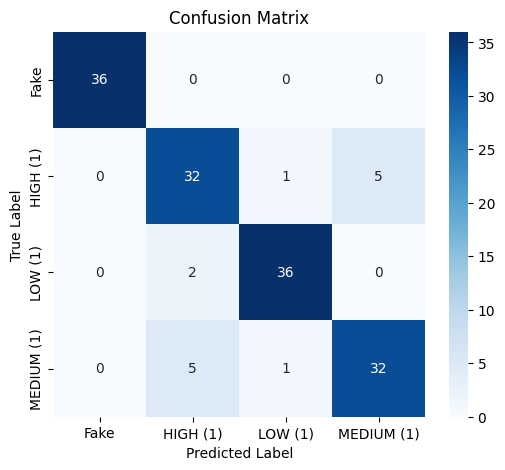

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(true_labels, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.pdf', format='pdf', dpi=300)
plt.show()


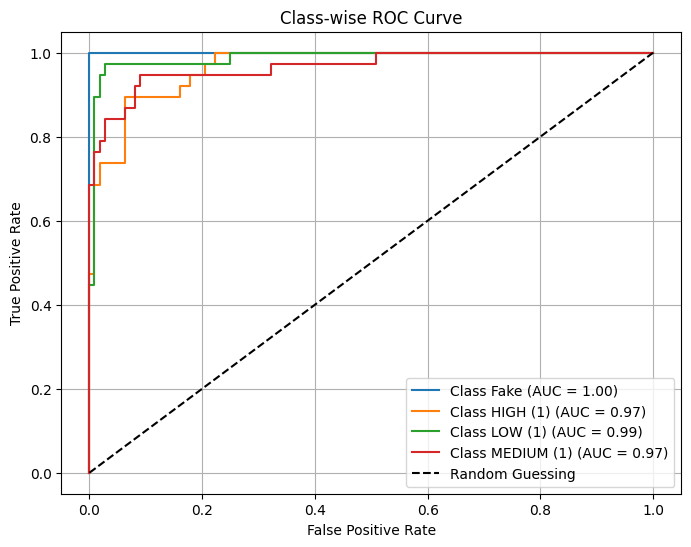

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Step 1: Convert true labels to one-hot encoding
num_classes = len(class_names)
true_labels_one_hot = label_binarize(true_labels, classes=np.arange(num_classes))

# Step 2: Compute ROC curve and AUC for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

# Step 3: Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")

# Step 4: Graph settings
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Class-wise ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('Class-wise Roc.pdf', format='pdf', dpi=300)
plt.show()


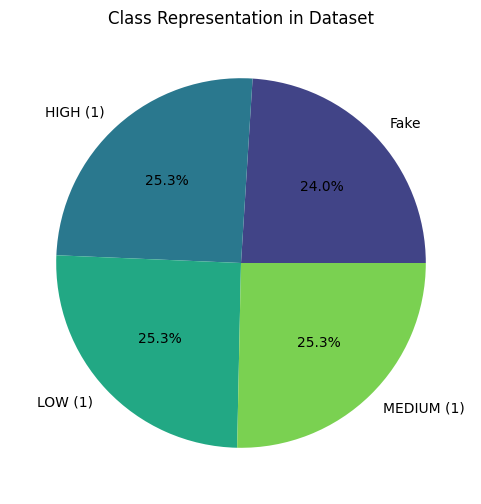

In [ ]:
plt.figure(figsize=(6, 6))
class_counts = np.bincount(true_labels)
plt.pie(class_counts, labels=class_names, autopct="%1.1f%%", colors=sns.color_palette("viridis", len(class_names)))
plt.title("Class Representation in Dataset")
plt.savefig('Piechart.pdf', format='pdf', dpi=300)
plt.show()


<ipython-input-15-79dc5028b2d1>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts, palette="viridis")


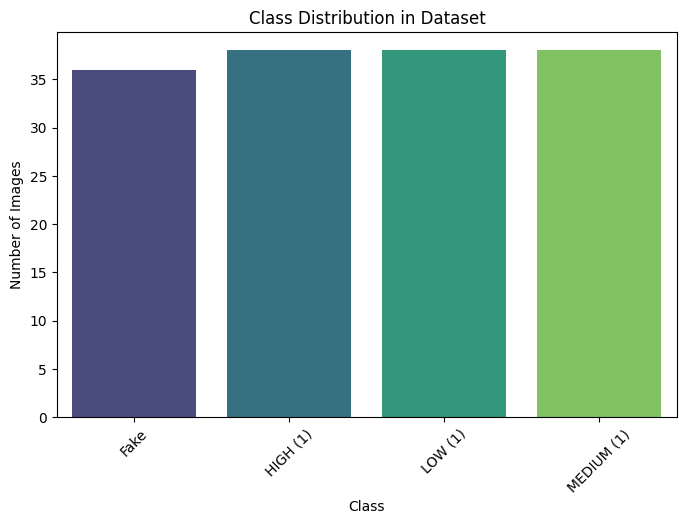

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts, palette="viridis")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)
plt.savefig('Barplot.pdf', format='pdf', dpi=300)
plt.show()

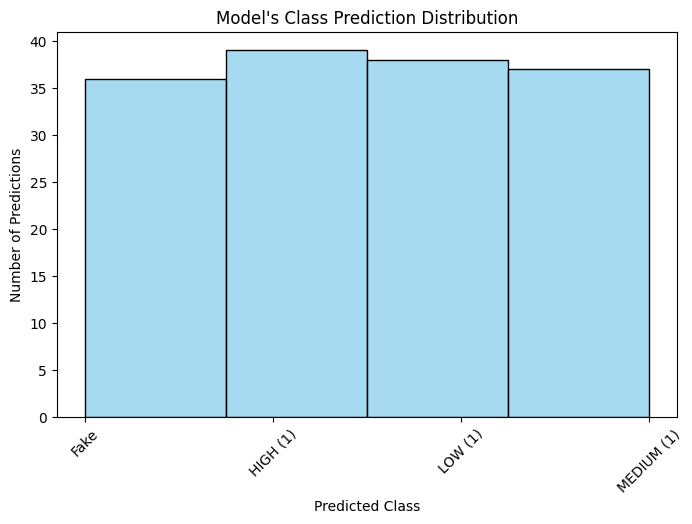

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(y_pred_classes, bins=len(class_names), kde=False, color="skyblue")
plt.xlabel("Predicted Class")
plt.ylabel("Number of Predictions")
plt.title("Model's Class Prediction Distribution")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.savefig('Histplot.pdf', format='pdf', dpi=300)
plt.show()


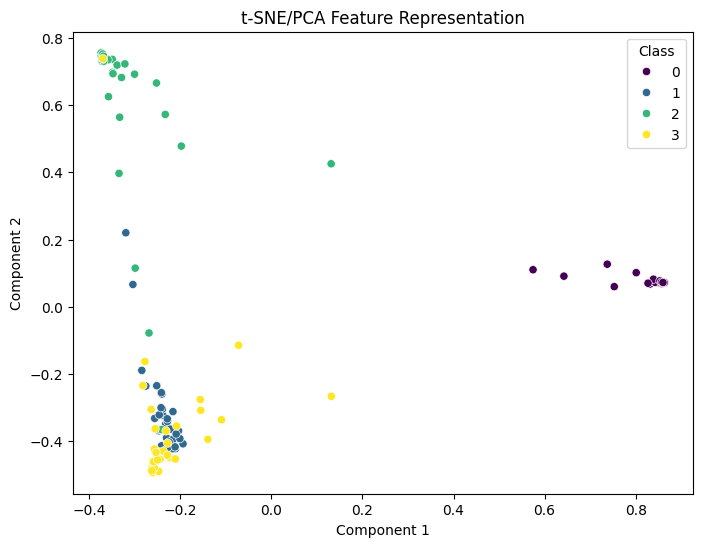

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(y_pred_probs)

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=true_labels, palette="viridis")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("t-SNE/PCA Feature Representation")
plt.legend(title="Class")
plt.savefig('Scatterplot.pdf', format='pdf', dpi=300)
plt.show()


In [ ]:
import os
from huggingface_hub import from_pretrained_fastai, login

# Log in with your Hugging Face token
token = os.getenv("HF_TOKEN")
if token:
    login(token=token)
else:
    login()

# Now load the pretrained model
learn = from_pretrained_fastai("Suhani-2407/MobileNet_Fire")

# Continue with prediction as before
from fastai.vision.all import *
img = PILImage.create('path/to/your/image.jpg')
pred_class, pred_idx, probabilities = learn.predict(img)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

MobileNet_model.h5:   0%|          | 0.00/14.7M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/119 [00:00<?, ?B/s]

requirements.txt:   0%|          | 0.00/45.0 [00:00<?, ?B/s]

app.py:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

model-index.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

There is no `pyproject.toml` in the repository that contains the fastai `Learner`. The `pyproject.toml` would allow us to verify that your fastai and fastcore versions are compatible with those of the model you want to load.
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/huggingface/hub/models--Suhani-2407--MobileNet_Fire/snapshots/c87e49e081a6fd7b4b8f0f97dd6a3ff907e4b2ee/model.pkl'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import glob

# Path to the downloaded model file
model_path = '/root/.cache/huggingface/hub/models--Suhani-2407--MobileNet_Fire/snapshots/c87e49e081a6fd7b4b8f0f97dd6a3ff907e4b2ee/MobileNet_model.h5'

# Check if the file exists or find it
if not os.path.exists(model_path):
    print(f"Model file not found at {model_path}")
    cache_dir = '/root/.cache/huggingface/hub/models--Suhani-2407--MobileNet_Fire/'
    model_files = glob.glob(f"{cache_dir}/**/*.h5", recursive=True)
    print("Found model files:", model_files)

    if model_files:
        model_path = model_files[0]
    else:
        raise FileNotFoundError("Could not find any .h5 model files")

# Load the model
model = load_model(model_path)

# Function to make predictions
def predict_fire_severity(img_path):
    # Load and preprocess the image - using 128x128 as required by the model
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    # Make prediction
    predictions = model.predict(img_array)

    # Define the classes
    classes = ['Fake', 'Low', 'Medium', 'High']

    # Get the predicted class index
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_class_index]
    confidence = predictions[0][predicted_class_index]

    return predicted_class, confidence, predictions[0]

# Example usage - replace with your actual image path
image_path = '/content/download (1).jpeg'  # Replace with your image path

# Try prediction
try:
    predicted_class, confidence, all_confidences = predict_fire_severity(image_path)
    print(f"Predicted Fire Severity: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")

    # Show all class probabilities
    classes = ['Fake', 'Low', 'Medium', 'High']
    for i, cls in enumerate(classes):
        print(f"{cls}: {all_confidences[i]:.4f}")

except Exception as e:
    print(f"Error during prediction: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Fire Severity: Fake
Confidence: 0.9275
Fake: 0.9275
Low: 0.0078
Medium: 0.0539
High: 0.0108


In [ ]:
!pip show keras

Name: keras
Version: 3.8.0
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow


In [ ]:
import requests
import json
from PIL import Image
import io
import base64

import os

# Your Hugging Face token
HF_TOKEN = os.getenv("HF_TOKEN", "YOUR_HF_TOKEN_HERE")

def predict_fire_severity_api(image_path):
    # Load the image
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    # Encode image to base64
    encoded_image = base64.b64encode(image_bytes).decode("utf-8")

    # API endpoint for the model
    api_url = "https://api-inference.huggingface.co/models/Suhani-2407/MobileNet_Fire"

    # Headers with authorization
    headers = {
        "Authorization": f"Bearer {HF_TOKEN}",
        "Content-Type": "application/json"
    }

    # Prepare payload
    payload = {
        "inputs": {
            "image": encoded_image
        }
    }

    # Make API request
    response = requests.post(api_url, headers=headers, json=payload)

    if response.status_code == 200:
        result = response.json()
        # Parse results - format depends on model output structure
        classes = ['Fake', 'Low', 'Medium', 'High']

        # Assuming the model returns a list of class probabilities
        # You might need to adjust this based on the actual response format
        if isinstance(result, list) and len(result) == len(classes):
            predicted_class_index = result.index(max(result))
            predicted_class = classes[predicted_class_index]
            confidence = result[predicted_class_index]
            return predicted_class, confidence, result
        else:
            # Handle different response format
            print("Unexpected response format:", result)
            return None, None, None
    else:
        print(f"Error: {response.status_code}")
        print(response.text)
        return None, None, None

# Example usage
image_path = '/content/download (1).jpeg'  # Replace with your image path
predicted_class, confidence, all_confidences = predict_fire_severity_api(image_path)

if predicted_class:
    print(f"Predicted Fire Severity: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")

    # Show all class probabilities
    classes = ['Fake', 'Low', 'Medium', 'High']
    for i, cls in enumerate(classes):
        print(f"{cls}: {all_confidences[i]:.4f}")

Error: 503
<!DOCTYPE html>
<html class="" lang="en">
<head>
    <meta charset="utf-8" />
    <meta
            name="viewport"
            content="width=device-width, initial-scale=1.0, user-scalable=no"
    />
    <meta
            name="description"
            content="We're on a journey to advance and democratize artificial intelligence through open source and open science."
    />
    <meta property="fb:app_id" content="1321688464574422" />
    <meta name="twitter:card" content="summary_large_image" />
    <meta name="twitter:site" content="@huggingface" />
    <meta
            property="og:title"
            content="Hugging Face - The AI community building the future."
    />
    <meta property="og:type" content="website" />

    <title>Hugging Face - The AI community building the future.</title>
    <style>
        body {
            margin: 0;
        }

        main {
            background-color: white;
            min-height: 100vh;
            padding: 7rem 1rem 8rem 1re

In [ ]:
from huggingface_hub import InferenceClient
import PIL.Image

# Initialize the client with your token
import os
client = InferenceClient(token=os.getenv("HF_TOKEN"))

# Load your image
image = PIL.Image.open('/content/download (1).jpeg')

# Make a prediction request
response = client.post(
    model="Suhani-2407/MobileNet_Fire",
    data=image
)

# Process the response
print(response)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)


TypeError: Image.seek() takes 2 positional arguments but 3 were given

In [ ]:
from huggingface_hub import InferenceClient
import PIL.Image
import io

# Initialize the client with your token
import os
client = InferenceClient(token=os.getenv("HF_TOKEN"))

# Load your image
image_path = '/content/download (1).jpeg'
image = PIL.Image.open(image_path)

# Convert PIL Image to bytes
img_byte_arr = io.BytesIO()
image.save(img_byte_arr, format=image.format if image.format else 'JPEG')
img_bytes = img_byte_arr.getvalue()

# Make a prediction request using the image-classification task
response = client.image_classification(
    model="Suhani-2407/MobileNet_Fire",
    images=img_bytes  # Using 'images' instead of 'data'
)

# Process the response
print(response)

TypeError: InferenceClient.image_classification() got an unexpected keyword argument 'images'

In [ ]:
from huggingface_hub import from_pretrained_fastai
from fastai.vision.all import *
import os

def predict_fire_severity_fastai(image_path):
    """
    Predict fire severity using a fastai model from Hugging Face Hub

    Args:
        image_path: Path to the image file

    Returns:
        predicted class, confidence, and all class probabilities
    """
    print("Loading model from Hugging Face...")
    # This will download the model if it's not in cache
    # but uses fastai's efficient approach
    learn = from_pretrained_fastai(
        "Suhani-2407/MobileNet_Fire",
        # Optionally specify a token if needed
        token=os.getenv("HF_TOKEN")
    )

    print("Model loaded successfully!")

    # Load the image
    img = PILImage.create(image_path)

    # Make prediction
    pred_class, pred_idx, probabilities = learn.predict(img)

    # Get class names and confidence values
    classes = learn.dls.vocab if hasattr(learn.dls, 'vocab') else ['Fake', 'Low', 'Medium', 'High']
    confidence = float(probabilities[pred_idx])
    all_confidences = [float(p) for p in probabilities]

    return pred_class, confidence, all_confidences, classes

# Example usage
try:
    image_path = '/content/download (1).jpeg'  # Replace with your image path

    pred_class, confidence, all_confidences, classes = predict_fire_severity_fastai(image_path)

    print(f"Predicted Fire Severity: {pred_class}")
    print(f"Confidence: {confidence:.4f}")

    # Show all class probabilities
    for i, cls in enumerate(classes):
        print(f"{cls}: {all_confidences[i]:.4f}")

except Exception as e:
    print(f"Error during prediction: {e}")
    import traceback
    traceback.print_exc()

Loading model from Hugging Face...
Error during prediction: from_pretrained_fastai() got an unexpected keyword argument 'token'


Traceback (most recent call last):
  File "<ipython-input-5-8fded9f01f65>", line 43, in <cell line: 0>
    pred_class, confidence, all_confidences, classes = predict_fire_severity_fastai(image_path)
                                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-5-8fded9f01f65>", line 18, in predict_fire_severity_fastai
    learn = from_pretrained_fastai(
            ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py", line 114, in _inner_fn
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
TypeError: from_pretrained_fastai() got an unexpected keyword argument 'token'


In [ ]:
from huggingface_hub import from_pretrained_fastai, login
from fastai.vision.all import *
import os

# First login with your token
token = os.getenv("HF_TOKEN")
if token:
    login(token=token)
else:
    login()

def predict_fire_severity_fastai(image_path):
    print("Loading model from Hugging Face...")
    # This will download the model if it's not in cache
    learn = from_pretrained_fastai("Suhani-2407/MobileNet_Fire")

    print("Model loaded successfully!")

    # Load the image
    img = PILImage.create(image_path)

    # Make prediction
    pred_class, pred_idx, probabilities = learn.predict(img)

    # Get class names and confidence values
    classes = learn.dls.vocab if hasattr(learn.dls, 'vocab') else ['Fake', 'Low', 'Medium', 'High']
    confidence = float(probabilities[pred_idx])
    all_confidences = [float(p) for p in probabilities]

    return pred_class, confidence, all_confidences, classes

# Example usage
try:
    image_path = '/content/download (1).jpeg'  # Replace with your image path

    pred_class, confidence, all_confidences, classes = predict_fire_severity_fastai(image_path)

    print(f"Predicted Fire Severity: {pred_class}")
    print(f"Confidence: {confidence:.4f}")

    # Show all class probabilities
    for i, cls in enumerate(classes):
        print(f"{cls}: {all_confidences[i]:.4f}")

except Exception as e:
    print(f"Error during prediction: {e}")
    import traceback
    traceback.print_exc()

Loading model from Hugging Face...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

app.py:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

...

model-index.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

MobileNet_model.h5:   0%|          | 0.00/14.7M [00:00<?, ?B/s]

There is no `pyproject.toml` in the repository that contains the fastai `Learner`. The `pyproject.toml` would allow us to verify that your fastai and fastcore versions are compatible with those of the model you want to load.


Error during prediction: [Errno 2] No such file or directory: '/root/.cache/huggingface/hub/models--Suhani-2407--MobileNet_Fire/snapshots/c87e49e081a6fd7b4b8f0f97dd6a3ff907e4b2ee/model.pkl'


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
Traceback (most recent call last):
  File "<ipython-input-6-fe57844887c2>", line 41, in <cell line: 0>
    pred_class, confidence, all_confidences, classes = predict_fire_severity_fastai(image_path)
                                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-6-fe57844887c2>", line 20, in predict_fire_severity_fastai
    learn = from_pretrained_fastai("Suhani-2407/MobileNet_Fire")
     

In [ ]:
# Set the backend to JAX
import os
os.environ["KERAS_BACKEND"] = "jax"

# Import necessary libraries
import keras
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from huggingface_hub import login

import os

# Login to Hugging Face with your API token
token = os.getenv("HF_TOKEN")
if token:
    login(token=token)
else:
    login()

# Load the model from Hugging Face
print("Loading model from Hugging Face...")
model = keras.saving.load_model("hf://Suhani-2407/MobileNet_Fire")
print("Model loaded successfully!")

# Define class names
classes = ['Fake', 'Low', 'Medium', 'High']

# Function to preprocess image for MobileNet
def preprocess_image(image_path, target_size=(224, 224)):
    # For URL images
    if isinstance(image_path, str) and image_path.startswith('http'):
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content))
    # For local images
    else:
        img = Image.open(image_path)

    img = img.resize(target_size)
    img = np.array(img)
    img = img / 255.0  # Normalize to [0,1]
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Function to make prediction
def predict_fire_severity(image_path):
    # Preprocess the image
    processed_image = preprocess_image(image_path)

    # Make prediction
    probabilities = model.predict(processed_image)[0]

    # Get predicted class index and name
    pred_idx = np.argmax(probabilities)
    pred_class = classes[pred_idx]

    # Get confidence values
    confidence = float(probabilities[pred_idx])
    all_confidences = [float(p) for p in probabilities]

    return pred_class, confidence, all_confidences, classes

# Example usage
def print_prediction(image_path):
    pred_class, confidence, all_confidences, classes = predict_fire_severity(image_path)

    print(f"Predicted class: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print("All confidence scores:")
    for i, (cls, conf) in enumerate(zip(classes, all_confidences)):
        print(f"  {cls}: {conf:.4f}")

# Use with an image file
print_prediction("/content/download (1).jpeg")

# For Colab, you can use:
# from google.colab import files
# uploaded = files.upload()
# image_path = next(iter(uploaded))
# print_prediction(image_path)

Loading model from Hugging Face...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

ValueError: Expected object to be an instance of `KerasSaveable`, but got {'name': 'sequential_8', 'trainable': True, 'dtype': <DTypePolicy "float32">, 'layers': [<InputLayer name=input_layer_15, built=True>, <Functional name=mobilenet_1.00_128, built=True>, <GlobalAveragePooling2D name=global_average_pooling2d_6, built=True>, <Dense name=dense_16, built=True>, <Dropout name=dropout_8, built=True>, <Dense name=dense_17, built=True>], 'build_input_shape': [None, 128, 128, 3]} of type <class 'dict'>

In [ ]:
!pip install tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.6
    Uninstalling protobuf-4.25.6:
      Successfully uninstalled protobuf-4.25.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.62.3 requires protobuf>=4.21.6, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.16.1 requires protobuf<6.0.0dev,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [ ]:
# First save your model in SavedModel format
import tensorflow as tf

# Load your model
model = tf.keras.models.load_model("/content/mobilenet_fire_repo/MobileNet_model.keras")

# Save in SavedModel format
model.save("mobilenet_savedmodel.keras")

# Now run the conversion using system command
import os
os.system("python -m tf2onnx.convert --saved-model mobilenet_savedmodel --output model.onnx")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


256

In [ ]:

import subprocess# Run the conversion with error output captured
conversion_command = "python -m tf2onnx.convert --saved-model mobilenet_savedmodel --output model.onnx"
result = subprocess.run(conversion_command, shell=True, capture_output=True, text=True)

# Print the output and error messages
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

# Check if file exists after conversion attempt
if os.path.exists("model.onnx"):
    print("ONNX file created successfully!")
    print("File size:", os.path.getsize("model.onnx"), "bytes")
else:
    print("ONNX file was not created.")

STDOUT: 
STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
E0000 00:00:1742410166.461989   27406 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742410166.468191   27406 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
<frozen runpy>:128: RuntimeWarning: 'tf2onnx.convert' found in sys.modules after import of package 'tf2onnx', but prior to execution of 'tf2onnx.convert'; this may result in unpredictable behaviour
2025-03-19 18:49:31,303 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
I0000 00:00:1742410171.478120   27406 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2450 MB memory:  -> device: 0, name: